### CONFIGURAÇÃO E FUNÇÕES

In [ ]:
import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import math

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
from math import ceil
import random
from tensorflow.keras import backend as K
import sys

#import wandb

2026-06-25 14:12:45.997119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-25 14:12:47.374162: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-25 14:12:47.733385: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-25 14:12:50.187950: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%load_ext autoreload
%autoreload 2

# Pega o diretório atual e sobe um nível ('..')
project_root = os.path.abspath('..')

# Adiciona este diretório ao sys.path se ele ainda não estiver lá
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Seus imports originais ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

In [3]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1782407627.546031    1700 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782407627.551727    1700 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782407627.551768    1700 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# FUNÇÕES
def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

def plot_roc_curve(y_true, y_probs, output_dir, mode, title):
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:
        y_true = np.argmax(y_true, axis=1)

    if len(y_probs.shape) > 1 and y_probs.shape[1] > 1:
        y_probs = y_probs[:, 1]

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel('False Positive Rate', fontsize=18)
    plt.ylabel('True Positive Rate', fontsize=18)
    plt.title(f'Receiver Operating Characteristic {title}', fontsize=24)
    plt.legend(loc="lower right", fontsize=15)
    
    plt.savefig(os.path.join(output_dir, f'roc_curve_{mode}.png'))
    plt.show()
    plt.close()
    
    print(f"AUC ({mode}): {roc_auc:.4f}")

# gerar curva AUC
def save_auc(test_pred, test_true_labels, results_dir, subset):
    if len(test_pred.shape) > 1 and test_pred.shape[1] > 1:
        y_probs = test_pred[:, 1]
    else:
        y_probs = test_pred

    auc_value = roc_auc_score(test_true_labels, y_probs)

    # Salvar o valor em um arquivo de texto
    with open(os.path.join(results_dir, f"{subset}_auc.txt"), "w") as f:
        f.write(f"AUC Score: {auc_value:.4f}")

    print(f"AUC da Validação: {auc_value:.4f}")

In [5]:
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

# Nome das classes
# adni_class_names = ['cn', 'mci', 'ad']
adni_class_names = ['cn', 'ad']
# oasis_class_names = ['0.0', '0.5', '1.0']
oasis_class_names = ['0.0', '1.0']

n_adni_classes = len(adni_class_names)
n_oasis_classes = len(oasis_class_names)

class_labels = adni_class_names

In [6]:
# Definindo caminhos
train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/CBM/experimentos'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['noise']

In [7]:
n = len(os.listdir(results_dir_base))
experiment_title = 'ADNI->ADNI mean standard deviation'

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir_base, os.listdir(results_dir_base)[n-1]))) < 2): 
        n -= 1

folder_name = f"test_experimentos_{str(n+1)}_{experiment_title}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_experimentos_2_ADNI->ADNI mean standard deviation criada


# Treino

In [9]:
# 1. CONFIGURAÇÃO DOS EXPERIMENTOS

# Experimento base 
EXP_AUGMENTATION_FACTOR = 0 # Mantém só originais
EXP_INCLUDE_INTENSITY = False # Transformações de geometria + intensidade
EXP_TRANSFORM_PROB = 0 # Sempre transforma

# Experimento 1
# EXP_AUGMENTATION_FACTOR = 0 # Mantém só originais
# EXP_INCLUDE_INTENSITY = False # Transformações de geometria + intensidade
# EXP_TRANSFORM_PROB = 1 # Sempre transforma

# Experimento 2
# EXP_AUGMENTATION_FACTOR = 3 # Cria 3 cópias
# EXP_INCLUDE_INTENSITY = False # Transformações de geometria + intensidade
# EXP_TRANSFORM_PROB = 1 # Sempre transforma

# Experimento 3
# EXP_AUGMENTATION_FACTOR = 7 # Cria 7 cópias 
# EXP_INCLUDE_INTENSITY = True # Transformações de geometria + intensidade
# EXP_TRANSFORM_PROB = 1 # Sempre transforma

# Experimento 3
# EXP_AUGMENTATION_FACTOR = 12 # Cria 11 cópias 
# EXP_INCLUDE_INTENSITY = True # Transformações de geometria + intensidade
# EXP_TRANSFORM_PROB = 1 # Sempre transforma

print(f"--- CONFIGURAÇÃO EXPERIMENTO (BALANCED CV) ---")
print(f"Fator de Aumento Alvo: {EXP_AUGMENTATION_FACTOR}x (sobre a classe majoritária)")
print(f"Incluir Intensidade: {EXP_INCLUDE_INTENSITY}")
print(f"Probabilidade Transform: {EXP_TRANSFORM_PROB}")
print("----------------------------------------------")

# CARREGAMENTO DOS DADOS
print("Carregando dados para memória...")
X_full_raw, y_full_indices, paths_raw, _ = proc_dados.load_nifti_data_from_multiple_sources(
    [train_dir, val_dir, test_dir], 
    class_labels, 
    augment=False, 
    target_per_class=667
)
print(f"Total de dados carregados: {len(X_full_raw)}")

--- CONFIGURAÇÃO EXPERIMENTO (BALANCED CV) ---
Fator de Aumento Alvo: 0x (sobre a classe majoritária)
Incluir Intensidade: False
Probabilidade Transform: 0
----------------------------------------------
Carregando dados para memória...
530 arquivos no diretorio cn - /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train
137 arquivos no diretorio cn - /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/validation
73 arquivos no diretorio cn - /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/test
534 arquivos no diretorio ad - /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train
152 arquivos no diretorio ad - /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/validation
76 arquivos no diretorio ad - /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/test
Total de dados carregados: 1334


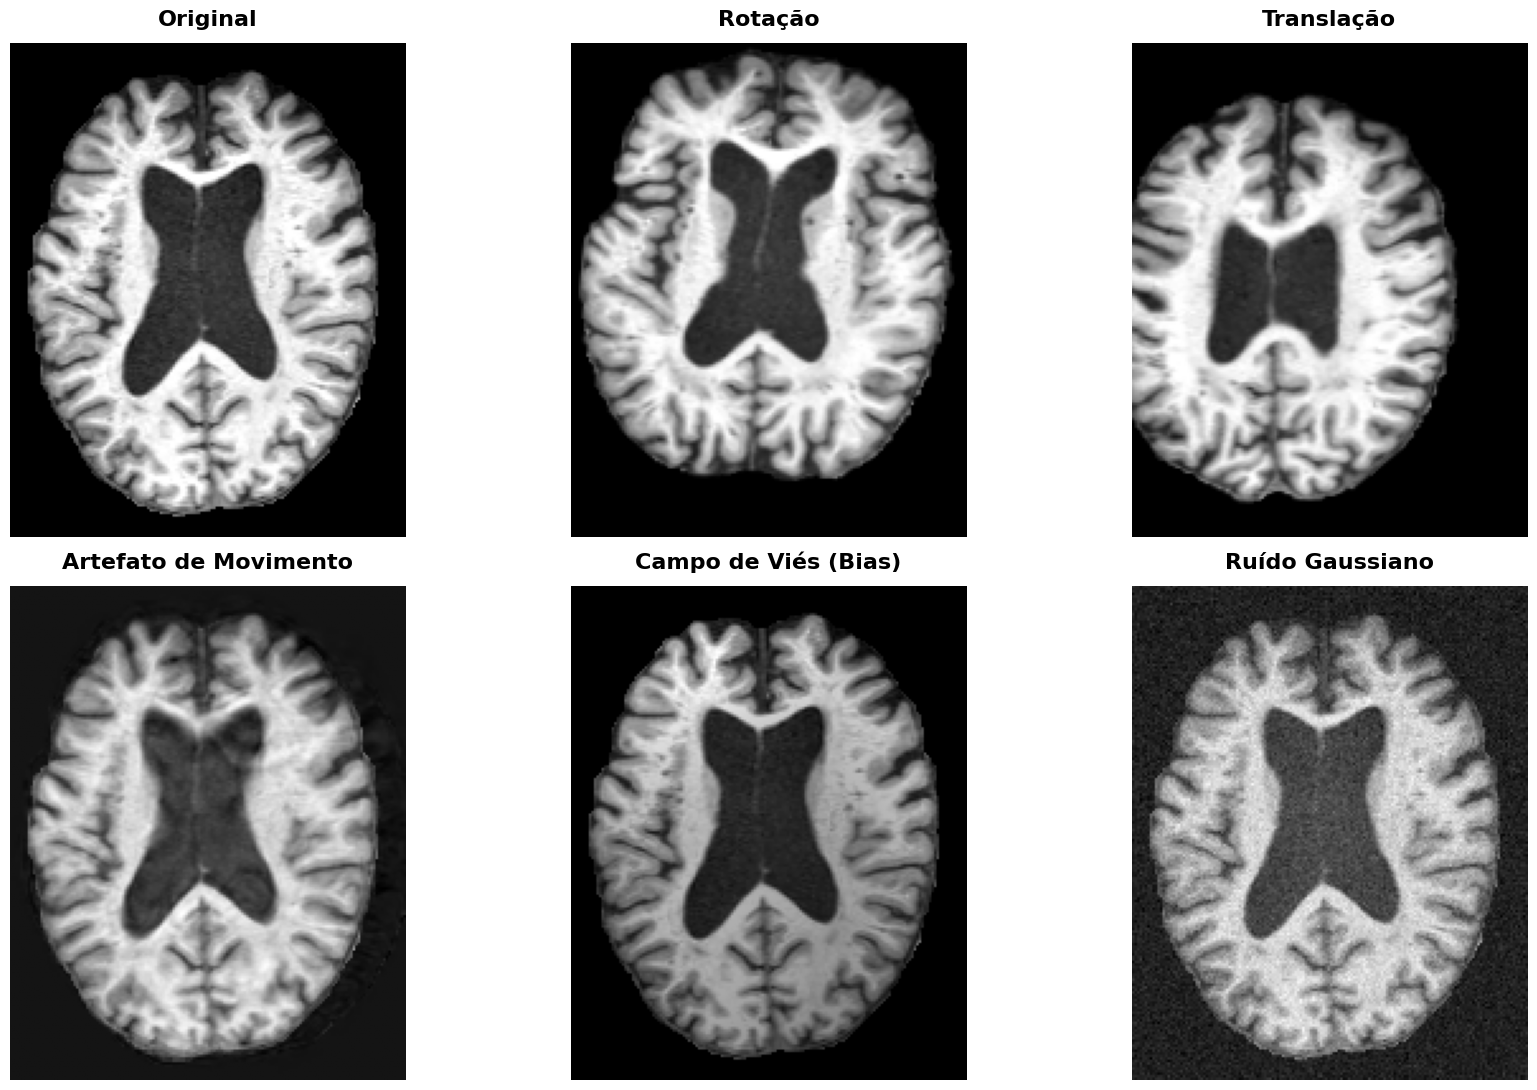


[SUCESSO] Grade simétrica 3x2 salva como: grade_aumento_dados.png


In [ ]:
# def plotar_grade_aumento_dados_simetrica(X_array, caminho_salvamento="grade_aumento_dados.png"):
#     """
#     Gera uma grade simétrica de 2 linhas e 3 colunas (3x2) com a imagem original 
#     e as 5 principais transformações do pipeline do TorchIO.
#     """
#     # 1. Preparação dos Dados (Conversão para float32 para o SimpleITK)
#     img_original = X_array[0]
#     slice_idx = img_original.shape[2] // 2 
#     img_t = img_original.transpose(3, 0, 1, 2).astype(np.float32)
#     subject = tio.Subject(mri=tio.ScalarImage(tensor=img_t))
    
#     # 2. Definição das Transformações (Ajustado para exatamente 6 imagens no total)
#     transformacoes = {
#         "Original": None,
#         "Rotação": tio.RandomAffine(scales=(0.9, 1.1), degrees=20, p=1.0),
#         "Translação": tio.RandomAffine(degrees=5, translation=20, p=1.0),
#         "Artefato de Movimento": tio.RandomMotion(degrees=5, translation=5, p=1.0),
#         "Campo de Viés (Bias)": tio.RandomBiasField(p=1.0),
#         "Ruído Gaussiano": tio.RandomNoise(std=0.05, p=1.0)
#     }

#     # 3. Processamento das Fatias
#     lista_fatias = []
#     titulos = []

#     for nome, transformacao in transformacoes.items():
#         if transformacao is None:
#             fatia = img_original[:, :, slice_idx, 0]
#         else:
#             vol_trans = transformacao(subject)
#             img_trans_np = vol_trans.mri.data.numpy().transpose(1, 2, 3, 0)
#             fatia = img_trans_np[:, :, slice_idx, 0]
        
#         lista_fatias.append(np.rot90(fatia))
#         titulos.append(nome)

#     # 4. Criação da Grade Perfeita (2 linhas, 3 colunas)
#     fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor='white')
#     axes = axes.flatten()

#     for i in range(len(lista_fatias)):
#         axes[i].imshow(lista_fatias[i], cmap="gray")
#         axes[i].set_title(titulos[i], fontsize=16, fontweight='bold', pad=12)
#         axes[i].axis("off")

#     plt.tight_layout()
    
#     # Salva com alta resolução para o slide
#     plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
#     plt.show()
    
#     print(f"\n[SUCESSO] Grade simétrica 3x2 salva como: {caminho_salvamento}")

# # --- EXECUÇÃO ---
# plotar_grade_aumento_dados_simetrica(X_full_raw)


INICIANDO FOLD 1/5


I0000 00:00:1782408118.388207    1700 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782408118.388281    1700 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782408118.388300    1700 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782408118.864505    1700 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1782408118.864565    1700 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-25

Epoch 1/125


I0000 00:00:1782408125.292801   11126 service.cc:146] XLA service 0x7f4fd8014490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782408125.292850   11126 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-06-25 14:22:05.629622: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-25 14:22:06.487537: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-06-25 14:22:07.643781: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.1385 = f32[8,18,22,18,8]{4,3,2,1,0} reduce-window(f32[8,52,65,54,8]{4,3,2,1,0} %broadcast.1374, f32[] %constant.1375), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x1_1x0_1x0_0x0_0}, to_apply=%region_1.1381, metadata={op_type="AvgPool3D" op_

133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5378 - auc: 0.5633 - loss: 1.4095

2026-06-25 14:22:50.505448: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng20{k2=6,k3=0} for conv (f32[4,1,3,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[3,1,156,195,160]{4,3,2,1,0}, f32[3,4,156,195,160]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-06-25 14:22:50.892515: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.387155892s
Trying algorithm eng20{k2=6,k3=0} for conv (f32[4,1,3,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[3,1,156,195,160]{4,3,2,1,0}, f32[3,4,156,195,160]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackward

134/134 ━━━━━━━━━━━━━━━━━━━━ 63s 287ms/step - accuracy: 0.5811 - auc: 0.6184 - loss: 1.3292 - val_accuracy: 0.5019 - val_auc: 0.8120 - val_loss: 1.3703 - learning_rate: 5.0000e-04
Epoch 2/125
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 144ms/step - accuracy: 0.6851 - auc: 0.7421 - loss: 1.0929 - val_accuracy: 0.4906 - val_auc: 0.8453 - val_loss: 1.3391 - learning_rate: 5.0000e-04
Epoch 3/125
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 142ms/step - accuracy: 0.6795 - auc: 0.7348 - loss: 1.0513 - val_accuracy: 0.5131 - val_auc: 0.8381 - val_loss: 1.2775 - learning_rate: 5.0000e-04
Epoch 4/125
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.7104 - auc: 0.7780 - loss: 0.9631 - val_accuracy: 0.5056 - val_auc: 0.8504 - val_loss: 1.3760 - learning_rate: 5.0000e-04
Epoch 5/125
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 144ms/step - accuracy: 0.7310 - auc: 0.8009 - loss: 0.9160 - val_accuracy: 0.7378 - val_auc: 0.8416 - val_loss: 0.8666 - learning_rate: 5.0000e-04
Epoch 6/125
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/s

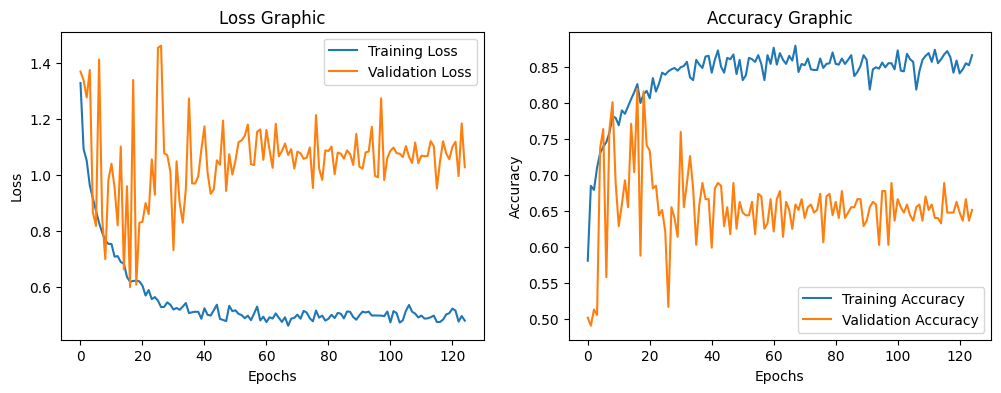

2026-06-25 15:01:56.790110: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 5198169600 exceeds 10% of free system memory.
2026-06-25 15:01:58.919928: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 5198169600 exceeds 10% of free system memory.


67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step


NameError: name 'f1_score' is not defined

In [10]:
# GERADOR DE DADOS 
def nifti_data_generator_3d(images_array, labels, batch_size):
    total_n = len(images_array)
    while True: 
        indices = np.random.permutation(total_n) 
        for i in range(0, total_n, batch_size):
            batch_idx = indices[i:i+batch_size]
            batch_images = np.array(images_array[batch_idx])
            batch_labels = np.array(labels[batch_idx])
            yield batch_images.astype(np.float16), batch_labels.astype(np.float16)


def get_augmentation_pipeline(include_intensity):
    spatial_transforms = tio.Compose([
        tio.RandomAffine(scales=(0.9, 1.1), degrees=15, isotropic=True, p=0.75),
        tio.RandomElasticDeformation(num_control_points=7, max_displacement=7.5, locked_borders=2, p=0.15)
    ])
    
    if include_intensity:
        artifact_transforms = tio.OneOf({
            tio.RandomBiasField(): 0.5, tio.RandomGhosting(): 0.2,
            tio.RandomMotion(degrees=5, translation=5): 0.2,
            tio.RandomNoise(std=0.05): 0.2, tio.RandomBlur(std=(0, 1)): 0.1,
        }, p=0.5)
        pipeline = tio.Compose([spatial_transforms, artifact_transforms])
    else:
        pipeline = spatial_transforms
    return pipeline

def balanced_data_generator(X, y, augment_factor, include_intensity, transform_prob):
    composer = None
    if augment_factor > 0:
        spatial = tio.Compose([
            tio.RandomAffine(scales=(0.9, 1.1), degrees=10, isotropic=True, p=0.75),
            tio.RandomElasticDeformation(num_control_points=7, max_displacement=7.5, locked_borders=2, p=0.15)
        ])
        if include_intensity:
            intensity = tio.OneOf({tio.RandomBiasField(): 0.5, tio.RandomNoise(): 0.1}, p=0.5)
            composer = tio.Compose([spatial, intensity])
        else:
            composer = spatial

    while True:
        # shuffle nos indices para garantir aleatoriedade em cada epoca
        indices = np.random.permutation(len(X))
        
        for idx in indices:
            img = X[idx]
            label = y[idx]
            
            # 1. sempre entrega a imagem original (1n)
            yield img.astype(np.float16), label.astype(np.float16)
            
            # 2. gera aumentos apenas se o fator for maior que 0
            for _ in range(int(augment_factor)):
                # so aplica transformacao se a probabilidade bater e o composer existir
                if composer and random.random() < transform_prob:
                    # prepara tensor (C, H, W, D) para o tio
                    img_t = img.transpose(3, 0, 1, 2)
                    subject = tio.Subject(mri=tio.ScalarImage(tensor=img_t))
                    
                    transformed = composer(subject)
                    img_aug = transformed.mri.data.numpy().transpose(1, 2, 3, 0)
                    yield img_aug.astype(np.float16), label.astype(np.float16)
                else:
                    # se nao houver aumento ou nao cair na prob, repete a original
                    yield img.astype(np.float16), label.astype(np.float16)

# ==============================================================================
# 4. LOOP 5-FOLD CROSS VALIDATION
# ==============================================================================
K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_accuracies = []
fold_aucs = []
aggregated_true_labels = []
aggregated_pred_labels = []
fold_f1_scores = []

BATCH_SIZE = 8
EPOCHS = 125

sample_shape = X_full_raw[0].shape
n_classes_fine_tuning = len(class_labels)

y_stratify = np.argmax(y_full_indices, axis=1)

for fold_idx, (train_index, val_index) in enumerate(skf.split(X_full_raw, y_stratify)):
    print(f"\n{'='*40}\nINICIANDO FOLD {fold_idx+1}/{K_FOLDS}\n{'='*40}")

    fold_dir = os.path.join(results_dir, f"fold_{fold_idx+1}")
    os.makedirs(fold_dir, exist_ok=True)

    X_train_fold = X_full_raw[train_index]
    y_train_fold = y_full_indices[train_index]
    X_val_fold = X_full_raw[val_index]
    y_val_fold = y_full_indices[val_index]

    # CONFIGURAÇÃO DO DATASET
    y_tr_idx = np.argmax(y_train_fold, axis=1)
    max_cnt_fold = max([np.sum(y_tr_idx == c) for c in np.unique(y_tr_idx)])
    
    # O equilíbrio agora é feito apenas pela quantidade de amostras geradas
    samples_per_class = max_cnt_fold * (1 + int(EXP_AUGMENTATION_FACTOR))
    total_train_samples = len(np.unique(y_tr_idx)) * samples_per_class
    steps_per_epoch = math.ceil(total_train_samples / BATCH_SIZE)
    
    # train_dataset = tf.data.Dataset.from_generator(
    #     lambda: balanced_data_generator(
    #         X_train_fold, y_train_fold, 
    #         EXP_AUGMENTATION_FACTOR, EXP_INCLUDE_INTENSITY, EXP_TRANSFORM_PROB
    #     ),
    #     output_signature=(
    #         tf.TensorSpec(shape=sample_shape, dtype=tf.float16),
    #         tf.TensorSpec(shape=(n_classes_fine_tuning,), dtype=tf.float16)
    #     )
    # ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Criamos o gerador bruto do Python
    raw_train_gen = nifti_data_generator_3d(X_train_fold, y_train_fold, BATCH_SIZE)
    raw_val_gen = nifti_data_generator_3d(X_val_fold, y_val_fold, BATCH_SIZE)

    # Encapsulamos no tf.data.Dataset para o TensorFlow gerenciar o ciclo de vida e as threads
    train_generator = tf.data.Dataset.from_generator(
        lambda: raw_train_gen,
        output_signature=(
            tf.TensorSpec(shape=(None, *sample_shape), dtype=tf.float16),
            tf.TensorSpec(shape=(None, n_classes_fine_tuning), dtype=tf.float16)
        )
    ).prefetch(tf.data.AUTOTUNE)

    val_generator = tf.data.Dataset.from_generator(
        lambda: raw_val_gen,
        output_signature=(
            tf.TensorSpec(shape=(None, *sample_shape), dtype=tf.float16),
            tf.TensorSpec(shape=(None, n_classes_fine_tuning), dtype=tf.float16)
        )
    ).prefetch(tf.data.AUTOTUNE)

    val_steps = math.ceil(len(X_val_fold) / BATCH_SIZE)

    # --- Modelo ---
    K.clear_session()
    tf.keras.backend.clear_session()
    gc.collect()

    model = create_model_3d(X_train_fold[0].shape, n_classes_fine_tuning)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)])

    # --- Treino ---
    checkpoint_path_fold = os.path.join(fold_dir, f"best_model_fold_{fold_idx+1}.keras")
    fold_last_path = os.path.join(fold_dir, f"last_model_{fold_idx+1}.keras")
    
    callbacks_list = [
        # EarlyStopping(monitor='val_loss', patience=30, verbose=1, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
        CSVLogger(os.path.join(fold_dir, 'training_log.csv')),
        ModelCheckpoint(filepath=checkpoint_path_fold, monitor='val_loss', 
                        save_best_only=True, mode='min'),
        ModelCheckpoint(fold_last_path, save_best_only=False)
    ]

    history = model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        validation_data=val_generator, 
        validation_steps=val_steps,
        callbacks=callbacks_list
    )

    # --- Avaliação ---
    met_vil.plot_training_history(history, fold_dir)

    del history
    del train_generator, val_generator
    for _ in range(3):
        gc.collect()

    val_pred_probs = model.predict(X_val_fold, batch_size=4)
    val_pred_labels = np.argmax(val_pred_probs, axis=1)
    val_true_labels = np.argmax(y_val_fold, axis=1)

    acc = accuracy_score(val_true_labels, val_pred_labels)
    auc_score = roc_auc_score(val_true_labels, val_pred_probs[:, 1])
    f1 = f1_score(val_true_labels, val_pred_labels, average='macro')

    fold_accuracies.append(acc)
    fold_aucs.append(auc_score)
    fold_f1_scores.append(f1)

    val_pos_probs = val_pred_probs[:, 1]

    met_vil.get_classification_report(val_true_labels, val_pred_labels, fold_dir, f'report_fold_{fold_idx+1}')
    met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, fold_dir, f'cm_fold_{fold_idx+1}', oasis_class_names) 
    save_auc(val_pos_probs, val_true_labels, fold_dir, 'test')
    plot_roc_curve(val_true_labels, val_pos_probs, fold_dir, 'validation', title='')

    aggregated_true_labels.extend(val_true_labels)
    aggregated_pred_labels.extend(val_pred_labels)

    print(f"Resultados Fold {fold_idx + 1} -> Acurácia: {acc:.4f} | AUC: {auc:.4f} | F1-Score: {f1:.4f}")

    # Limpeza agressiva ao final de cada fold
    del model, X_train_fold, X_val_fold, y_train_fold, y_val_fold
    del val_pred_probs, val_pred_labels, val_true_labels, val_pos_probs
    del y_tr_idx

    # Limpa sessão do Keras E do TF completamente
    K.clear_session()
    tf.keras.backend.clear_session()

    # Força coleta de lixo em múltiplas gerações
    for _ in range(3):
        gc.collect()

    print(f"Fold {fold_idx+1} finalizado. Memória liberada.")

### RESULTADOS GLOBAIS

In [ ]:
# FORA DO LOOP (depois que todos os folds finalizaram)
print("\n=================================================")
print("--- RESULTADOS FINAIS DO CROSS VALIDATION ---")
print("\n=================================================")

# Utilizando np.mean (média) e np.std (desvio padrão)
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)

mean_f1 = np.mean(fold_f1_scores)
std_f1 = np.std(fold_f1_scores)

print(f"Acurácia Média: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"AUC Média:      {mean_auc:.4f} ± {std_auc:.4f}")
print(f"F1-Score Médio: {mean_f1:.4f} ± {std_f1:.4f}")

# Opcional: Salvar esse resumo em um arquivo de texto
summary_path = os.path.join(results_dir, "cv_metrics_summary.txt")
with open(summary_path, "w") as f:
    f.write("Resultados da Validacao Cruzada por Folds\n")
    f.write("-----------------------------------------\n")
    f.write(f"Acurácia: {mean_acc:.4f} ± {std_acc:.4f}\n")
    f.write(f"AUC:      {mean_auc:.4f} ± {std_auc:.4f}\n")
    f.write(f"F1-Score: {mean_f1:.4f} ± {std_f1:.4f}\n")
    f.write("\nValores Individuais por Fold:\n")
    f.write(f"Acurácias: {fold_accuracies}\n")
    f.write(f"AUCs:      {fold_aucs}\n")


=== VALIDAÇÃO CRUZADA FINALIZADA ===
Acurácia Média: 0.9161 (+/- 0.1084)
AUC Média: 0.9860 (+/- 0.0204)


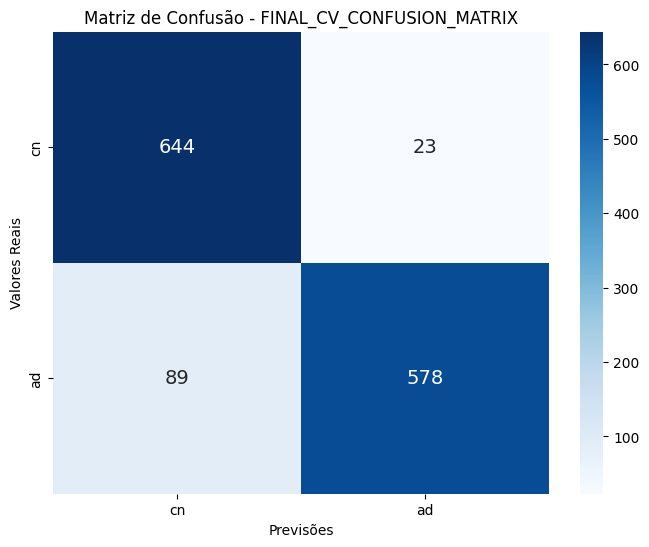

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       667
           1       0.96      0.87      0.91       667

    accuracy                           0.92      1334
   macro avg       0.92      0.92      0.92      1334
weighted avg       0.92      0.92      0.92      1334



In [ ]:
# ==============================================================================
# 5. RESULTADOS GLOBAIS
# ==============================================================================
print("\n=== VALIDAÇÃO CRUZADA FINALIZADA ===")
print(f"Acurácia Média: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"AUC Média: {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")

aggregated_true = np.array(aggregated_true_labels)
aggregated_pred = np.array(aggregated_pred_labels)

met_vil.plot_confusion_matrix(
    aggregated_true, 
    aggregated_pred, 
    results_dir, 
    'FINAL_CV_CONFUSION_MATRIX', 
    class_labels
)

met_vil.get_classification_report(
    aggregated_true, 
    aggregated_pred, 
    results_dir, 
    'FINAL_CV_REPORT'
)

### PREDIÇÃO TESTE PRE TREINO

In [ ]:
test_images, test_labels, test_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(test_dir, class_labels)

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions(test_images, test_labels, BATCH_SIZE, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, f"{results_dir}", 'test_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, f"{results_dir}", 'test_adni_pre_train', class_labels)

# Criar pdf com predições
test_pdf_path = os.path.join(f"{results_dir}/pretrained", "test_adni_predictions_pre_train.pdf")
met_vil.create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, class_labels)

save_auc(test_pred, test_true_labels, results_dir, 'test')